In [28]:
print("Working")

Working


In [1]:
# IQR = Q3 - Q1 || 75%tile - 25%tile

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
data = pd.read_csv('placement.csv')
data.sample(5)
data.shape

(1000, 3)

/tmp/ipykernel_17430/615477804.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['cgpa'])
/tmp/ipykernel_17430/615477804.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['placement_exam_marks'])


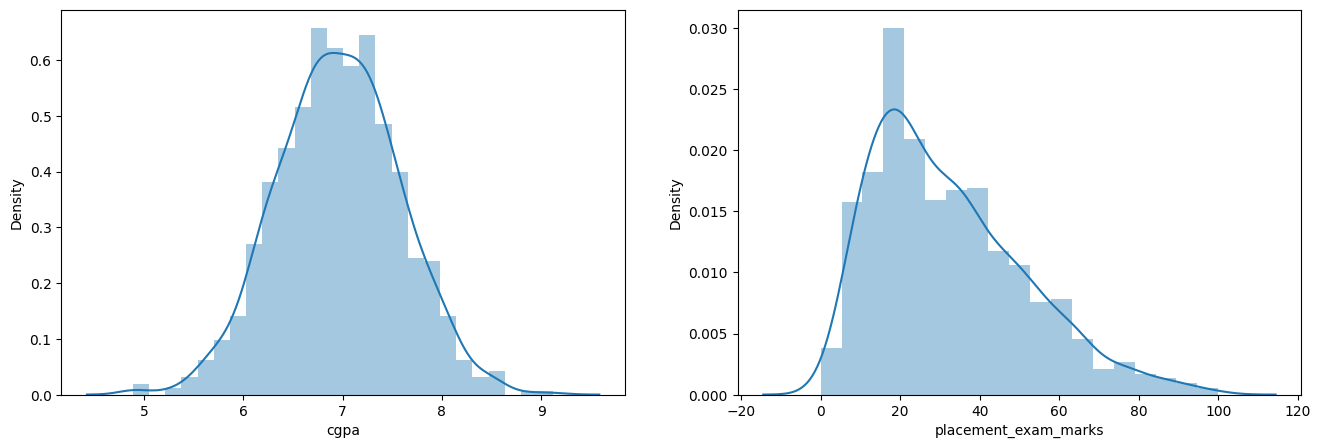

In [31]:
# Plotting
plt.figure(figsize=(16, 5))
plt.subplot(1,2,1)
sns.distplot(data['cgpa'])

plt.subplot(1,2,2)
sns.distplot(data['placement_exam_marks'])

plt.show()

In [32]:
# placement_exam_marks is not normally distributed, so we'll apply IQR Method on 'placement_exam_marks' column
data['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

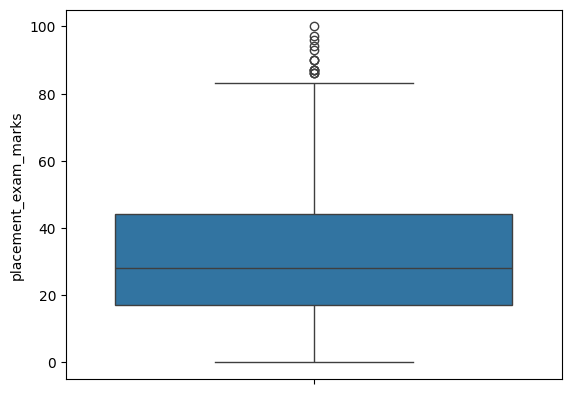

In [33]:
sns.boxplot(data['placement_exam_marks'])

In [34]:
# Calculate IQR
per25 = data['placement_exam_marks'].quantile(0.25)
per75 = data['placement_exam_marks'].quantile(0.75)
iqr = per75 - per25
print(iqr)

27.0


In [35]:
upper_limit = per75 + 1.5 * iqr
lower_limit = per25 - 1.5 * iqr
print(upper_limit)
print(lower_limit)

84.5
-23.5


### Triming

In [41]:
new_data = data[data['placement_exam_marks'] < upper_limit]
new_data.shape

(0, 3)

### Capping

In [45]:
new_cap_data = data.copy()
new_cap_data['placement_exam_marks'] = np.where(new_cap_data['placement_exam_marks'] > upper_limit, upper_limit, np.where(new_cap_data['placement_exam_marks'] < lower_limit, lower_limit, new_cap_data['placement_exam_marks']))

In [46]:
new_cap_data.shape

(1000, 3)

/tmp/ipykernel_17430/2307453857.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['placement_exam_marks'])
/tmp/ipykernel_17430/2307453857.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_cap_data['placement_exam_marks'])
/home/tanmay/Documents/AI_ML/venv/lib/python3.12/site-packa

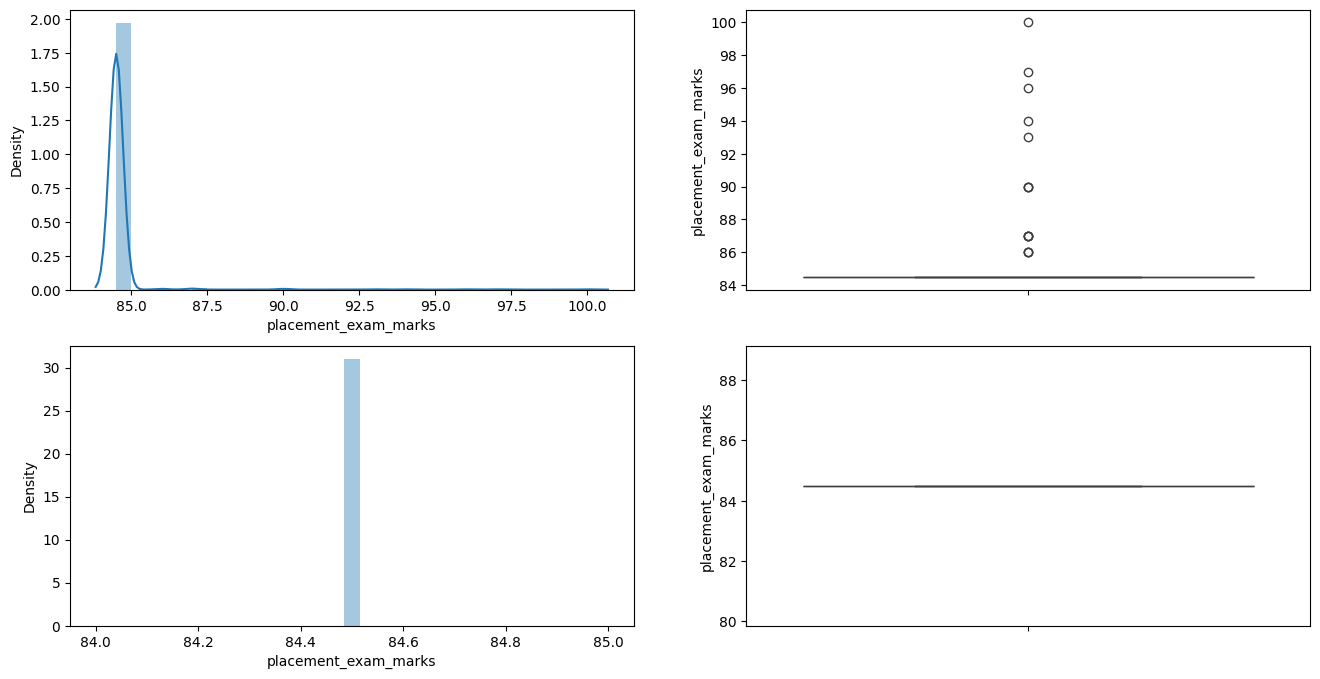

In [47]:
# Comparing
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(data['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(data['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_cap_data['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_cap_data['placement_exam_marks'])

plt.show()